In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from region import Region
from functions import Functions
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from gsw import conversions
from gsw import density
from cartopy.feature import LAND

In [4]:
sla_ = SLA(deg=0.25).da

minla = -68
maxla = -63

t1 = sla_.time[0]
t2 = sla_.time[-1]

extent_ac = [138,152,minla,maxla]
extent_ea=[60,160,-70,-60]

elevation = fns.elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = fns.elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

region_ac = Region('AC',extent_ac,elevation=elevation)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation,min_elevation=-1000)

In [5]:
sla = region_ac.crop_da(sla_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [6]:
f1 = '../data/GLORYS/glorys_001.nc'
f2 = '../data/GLORYS/glorys_002.nc'

In [7]:
ds1 = xr.open_dataset(f1)
ds2 = xr.open_dataset(f2)

In [8]:
ds = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))

/tmp/ipykernel_1327071/619345175.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))


In [9]:
glorys_sla_ = ds.zos - ds.zos.mean('time')
sla = sla - sla.mean('time')

In [10]:
# crop to same region
glorys_sla_cropped = region_ac.crop_da(glorys_sla_)

# filter dodgy sla signal
lonboo = glorys_sla_cropped.longitude < 147
latboo = glorys_sla_cropped.latitude > -66.6
glorys_sla = glorys_sla_cropped.where(lonboo | latboo,drop=True)

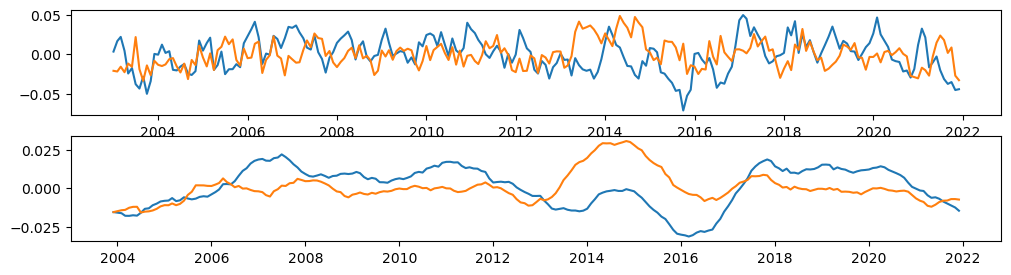

In [11]:
fig,ax = plt.subplots(2,1,figsize=(12,3))
ax[0].plot(ds.time,glorys_sla.mean(['latitude','longitude']),label='glorys')
ax[0].plot(sla.time,sla.mean(['latitude','longitude'])/100,label='sla')
ax[1].plot(ds.time,glorys_sla.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='glorys')
ax[1].plot(sla.time,sla.mean(['latitude','longitude']).rolling({'time':12}).mean()/100,label='sla')

In [12]:
u, v = fns.get_geostrophic_currents(ds.zos)
geos = xr.Dataset({'u10':u,'v10':v})

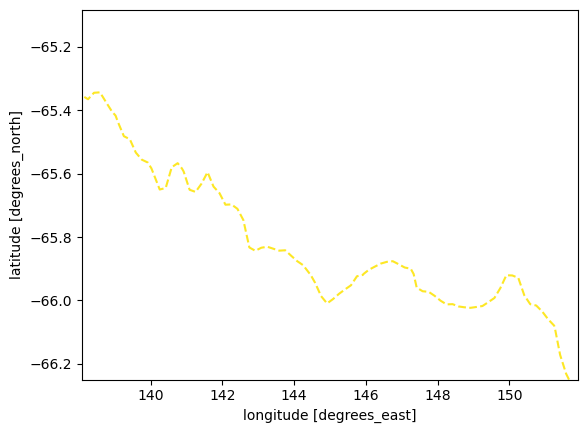

In [13]:
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=ds.longitude,kwargs={'fill_value':'extrapolate'})

# isolate asc on slope = -1000
ds['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':ds.longitude})
ds['asc'] = ds.uo.sel(latitude=ds.asc_latitude,method='nearest')

R = 6371000
lat_radians = np.deg2rad(ds.asc_latitude)

dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(ds.longitude))
dy = R * np.deg2rad(np.diff(ds.asc_latitude))

delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

# Interpolate u and v onto path points for all times
u_path = ds.uo.interp(latitude=ds.asc_latitude, longitude=ds.longitude)
v_path = ds.vo.interp(latitude=ds.asc_latitude, longitude=ds.longitude)

# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :, :]

dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})


v_along_o = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

In [14]:

# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=ds.asc_latitude, longitude=ds.longitude)
v_path = geos.v10.interp(latitude=ds.asc_latitude, longitude=ds.longitude)

# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]

dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})

v_along_a = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

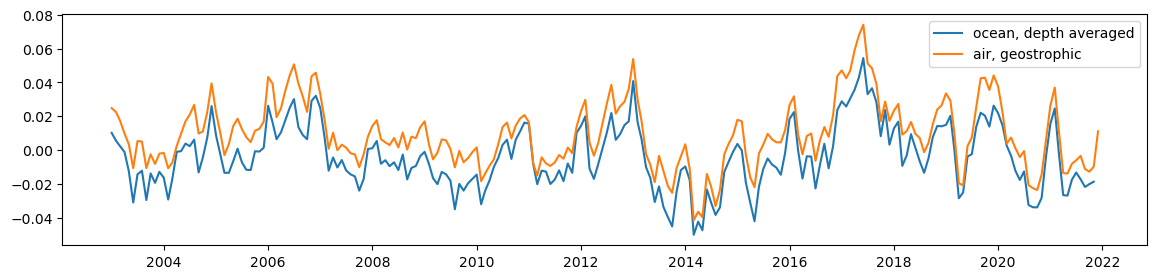

In [15]:
fig, ax = plt.subplots(figsize=(14,3))
ax.plot(v_along_o.time,v_along_o.mean(['longitude','depth']),label='ocean, depth averaged')
ax.plot(v_along_a.time,v_along_a.mean('longitude'),label='air, geostrophic')
ax.legend()

In [16]:
ds_sanom = ds.groupby('time.month') - ds.groupby('time.month').mean()


In [17]:
ds_2014a = ds_sanom.sel(time=slice(pd.Timestamp(2014,1,1),pd.Timestamp(2014,12,31))).mean('time')
ds_2007a = ds_sanom.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2007,12,31))).mean('time')

In [18]:
geos_sanom = geos.groupby('time.month') - geos.groupby('time.month').mean()
geos_2014a = geos_sanom.sel(time=slice(pd.Timestamp(2014,1,1),pd.Timestamp(2014,12,31))).mean('time')
geos_2007a = geos_sanom.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2007,12,31))).mean('time')

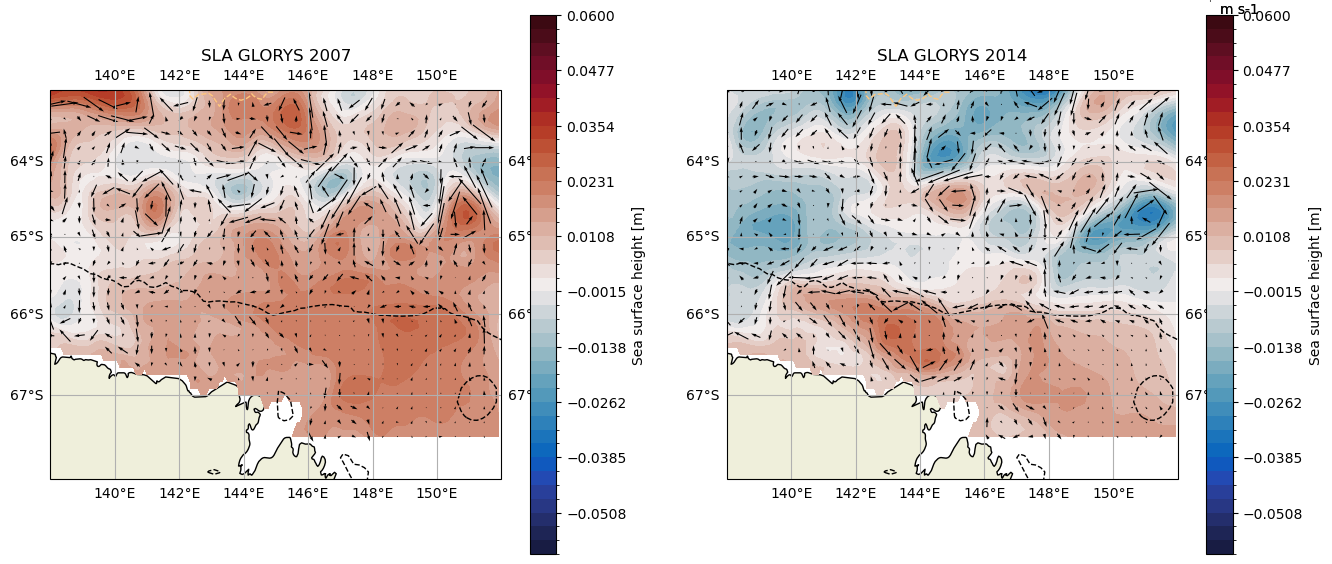

In [19]:
fig, ax = plt.subplots(1,2,figsize=(16,7),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax[0],ds_2007a.zos,'SLA GLORYS 2007',extent_ac,vmin=-0.06,vmax=0.06,vector=geos_2007a)
fns.plotc(ax[1],ds_2014a.zos,'SLA GLORYS 2014',extent_ac,vmin=-0.06,vmax=0.06,vector=geos_2014a)


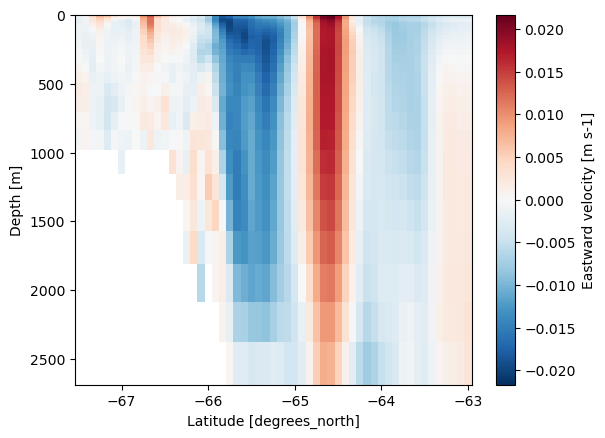

In [20]:
ds_2014a.uo.mean('longitude').plot()
plt.gca().invert_yaxis()

In [21]:
# compute density etc
def calc_vars(ds):
    ds['pressure'] = conversions.p_from_z(ds.depth,ds.latitude.mean())
    ds['rho'] = density.rho(ds.so,ds.thetao,ds.pressure)
    ds['sigma0'] = density.sigma0(ds.so,ds.thetao)

calc_vars(ds)


In [22]:
asc = -v_along_o.mean(['depth','longitude'])

In [23]:
# prepare other data
sa_sla = fns.seasonal_anomaly(region_ac.crop_da(sla))
sa_geos = fns.seasonal_anomaly(region_ac.crop_da(geos))
sa_glorys = fns.seasonal_anomaly(region_ac.crop_da(ds))
sa_glorys_shelf = fns.seasonal_anomaly(region_ac_shelf.crop_da(ds))
sa_asc = fns.seasonal_anomaly(asc)


In [24]:
ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_glorys = fns.season_split(sa_glorys)
ssn_glorys_shelf = fns.season_split(sa_glorys_shelf)
ssn_asc = fns.season_split(sa_asc)

In [27]:
cssh = sa_glorys_shelf.zos.mean(['latitude','longitude'])

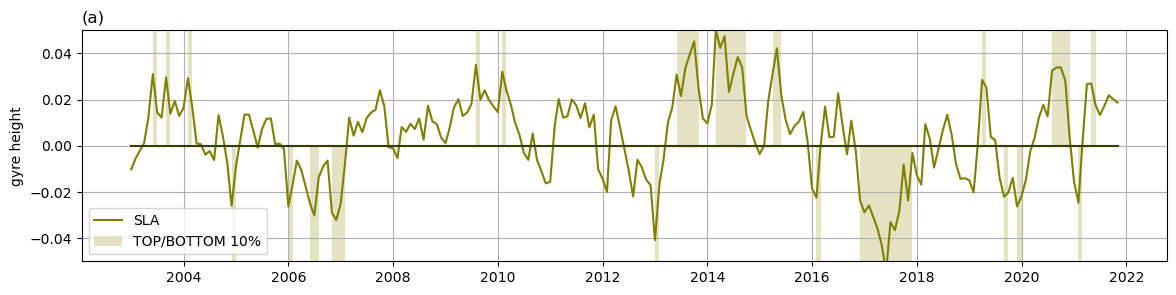

In [51]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(asc,frac)
fns.idx_ts(asc,frac,lag=lag,ylim_idx=0.05)

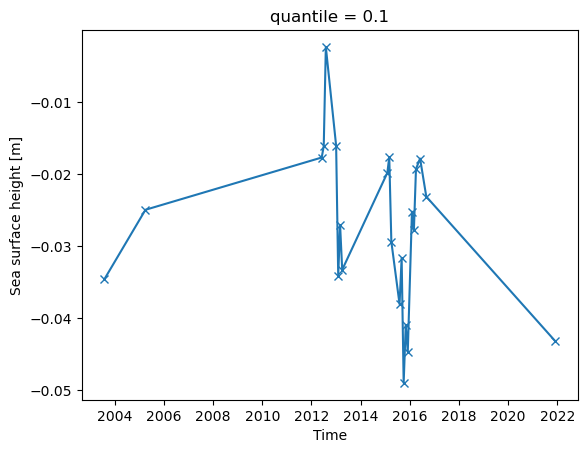

In [40]:
sa_glorys.zos.where(botboo,drop=True).mean(['latitude','longitude']).plot(marker='x')

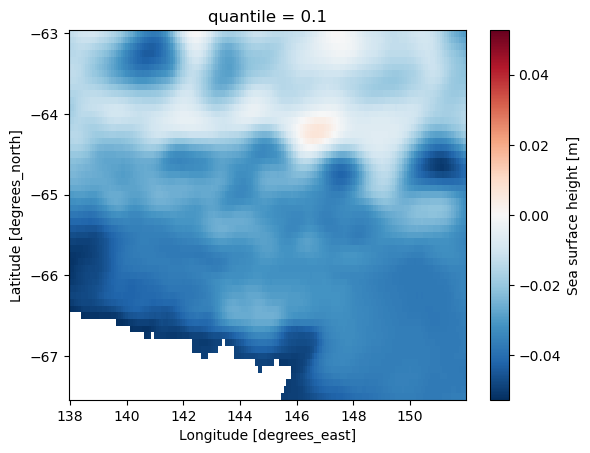

In [44]:
bot(sa_glorys.zos).plot()

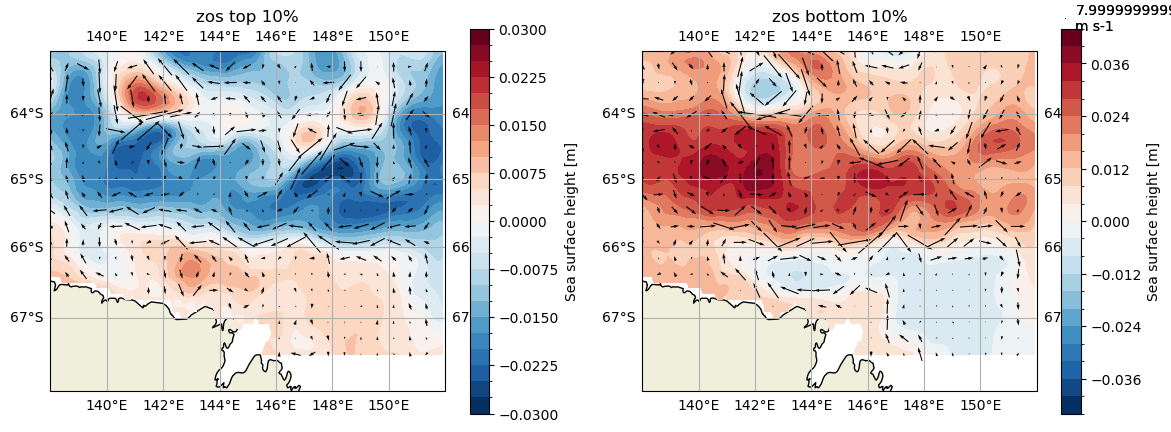

In [52]:
fig,axs=plt.subplots(1,2,figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})

ax=axs[0]
top(sa_glorys.zos).plot.contourf(ax=ax,x='longitude',y='latitude',transform=ccrs.PlateCarree(),levels=25)
top(sa_geos).plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=20)
ax.set_title('zos top 10%')
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

ax=axs[1]
bot(sa_glorys.zos).plot.contourf(ax=ax,x='longitude',y='latitude',transform=ccrs.PlateCarree(),levels=25)
bot(sa_geos).plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=20)
ax.set_title('zos bottom 10%')
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

In [53]:
sa_transect = sa_glorys.sel(longitude=145,method='nearest')

In [54]:
tops = top(sa_transect,lag)#ssn_sose[s],lag)
bots = bot(sa_transect,lag)#ssn_sose[s],lag)

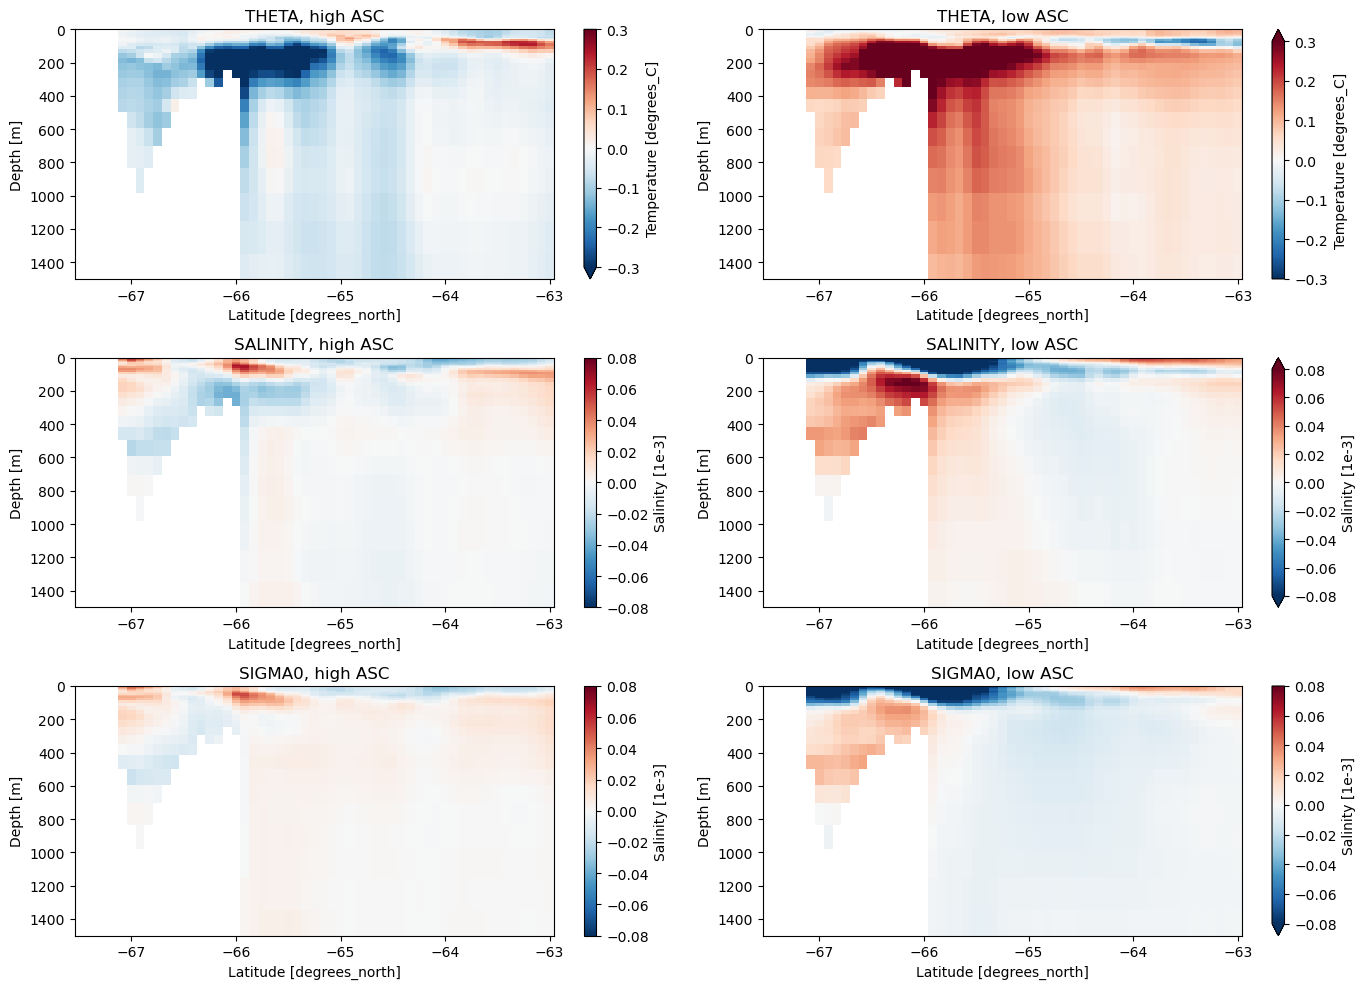

In [56]:
fig,axs = plt.subplots(3,2,figsize=(14,10))



z = 1500

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([0,z])
    ax.invert_yaxis()

    #ax.set_xlim([-67.5,-64.5])

lbl_high = 'high ASC'
lbl_low = 'low ASC'

ax = axs[0]
plot_transect(tops.thetao,ax[0],'THETA, '+ lbl_high,-0.3)
plot_transect(bots.thetao,ax[1],'THETA, ' + lbl_low,-0.3)

ax = axs[1]
plot_transect(tops.so,ax[0],'SALINITY, ' + lbl_high,-0.08)
plot_transect(bots.so,ax[1],'SALINITY, ' + lbl_low,-0.08)

ax = axs[2]
plot_transect(tops.sigma0,ax[0],'SIGMA0, ' + lbl_high,-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, ' + lbl_low,-0.08)

plt.tight_layout()

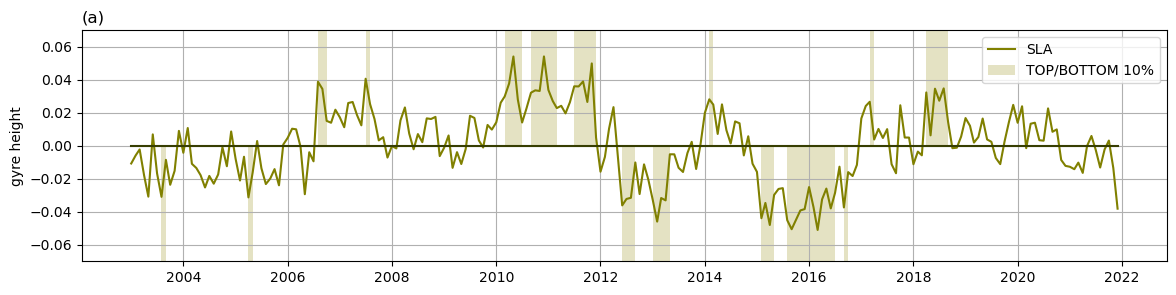

In [28]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(cssh,frac)
fns.idx_ts(cssh,frac,lag=lag,ylim_idx=0.07)

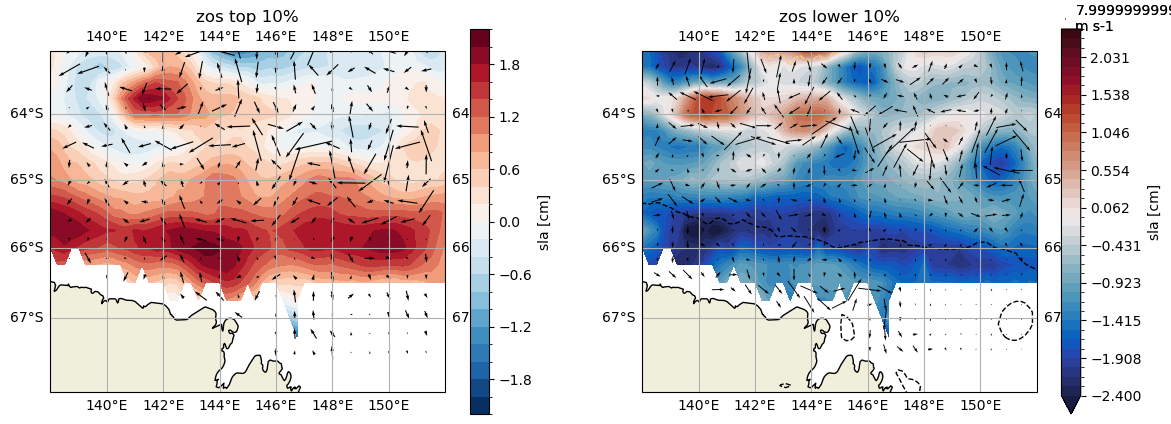

In [29]:
fig,axs=plt.subplots(1,2,figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})

ax=axs[0]
top(sa_sla).plot.contourf(ax=ax,x='longitude',y='latitude',transform=ccrs.PlateCarree(),levels=25)
top(sa_geos).plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=20)
ax.set_title('zos top 10%')
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

ax=axs[1]
fns.plotc(ax,bot(sa_sla),'zos lower 10%',extent_ac,-2.4,2.4,vector=bot(sa_geos))

    

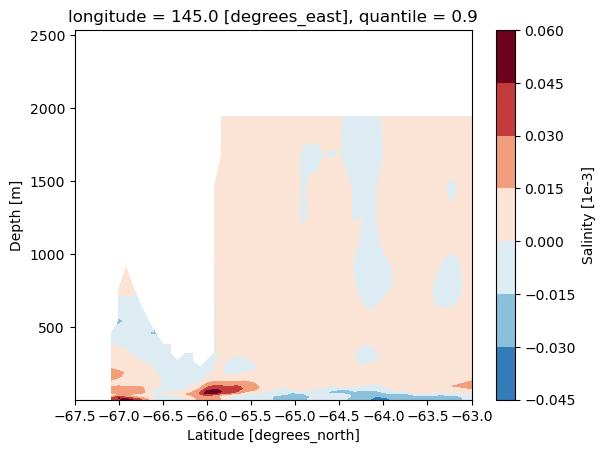

In [64]:
tops.sigma0.plot.contourf()


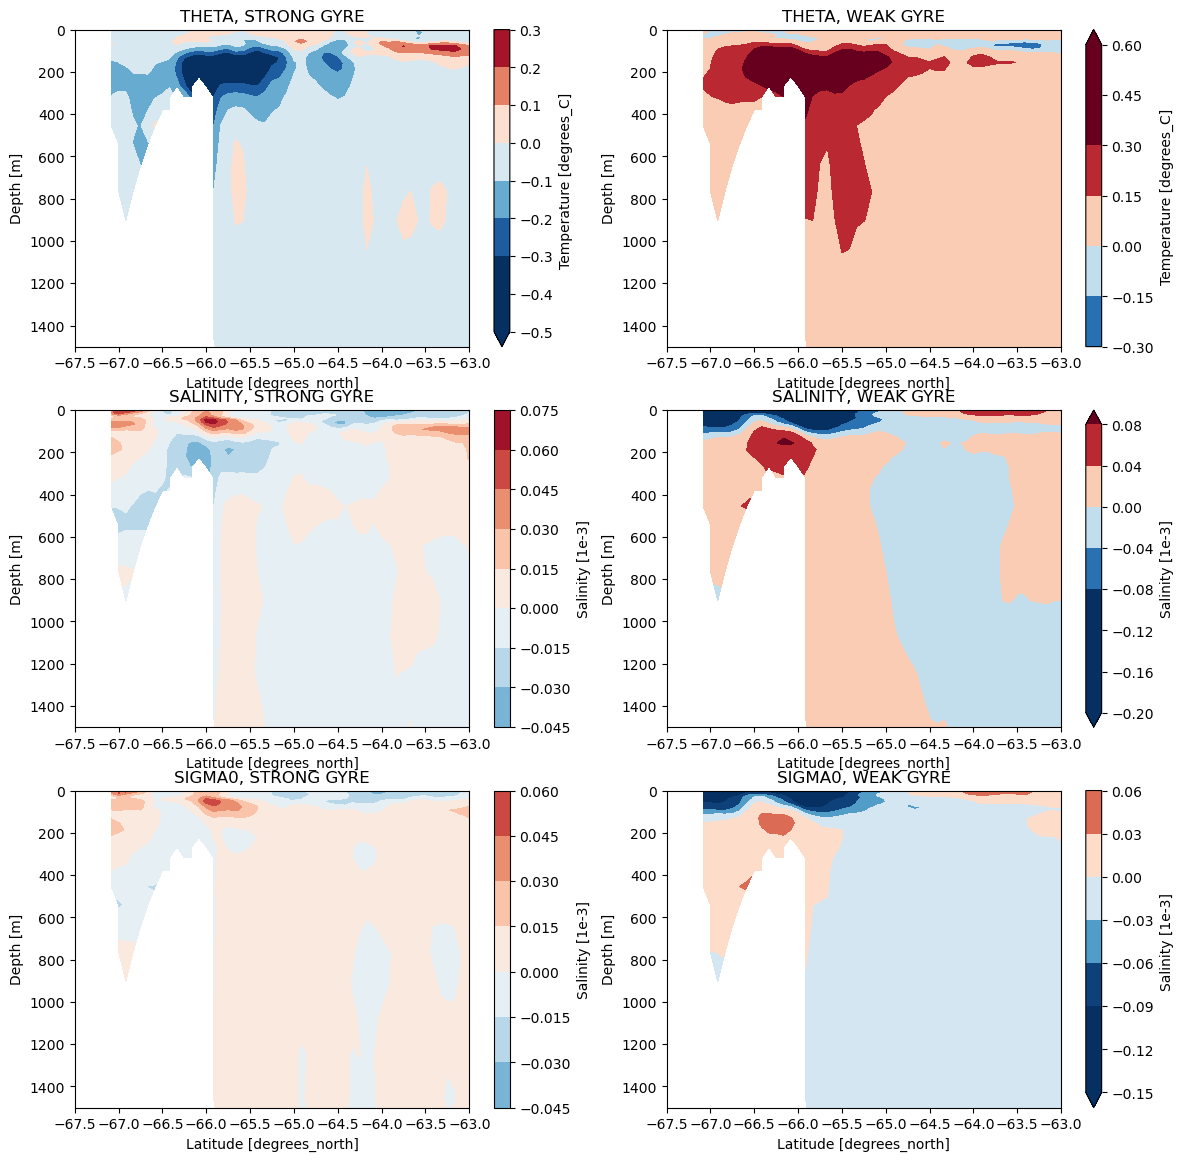

In [65]:
fig,axs = plt.subplots(3,2,figsize=(14,14))
tops = top(sa_transect,lag)#ssn_sose[s],lag)
bots = bot(sa_transect,lag)#ssn_sose[s],lag)


z = 1500

def plot_transect(data,ax,title,vmin):
    data.plot.contourf(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([0,z])
    ax.invert_yaxis()

    #ax.set_xlim([-67.5,-64.5])

ax = axs[0]
plot_transect(tops.thetao,ax[0],'THETA, STRONG GYRE',-0.3)
plot_transect(bots.thetao,ax[1],'THETA, WEAK GYRE',-0.3)

ax = axs[1]
plot_transect(tops.so,ax[0],'SALINITY, STRONG GYRE',-0.08)
plot_transect(bots.so,ax[1],'SALINITY, WEAK GYRE',-0.08)

ax = axs[2]
plot_transect(tops.sigma0,ax[0],'SIGMA0, STRONG GYRE',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, WEAK GYRE',-0.08)


In [36]:
# mean on shelf
shelf140 = sa_glorys.where(sa_glorys.depth < 1000,drop=True)
shelf145 = sa_glorys.where(sa_glorys.depth < 1000,drop=True)

In [57]:
sa_glorys.where(sa_glorys.depth < 1000,drop=True)

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 228, latitude: 55, longitude: 168, depth: 35)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-12-01
  * latitude      (latitude) float32 220B -67.5 -67.42 -67.33 ... -63.08 -63.0
  * longitude     (longitude) float32 672B 138.0 138.1 138.2 ... 151.8 151.9
  * depth         (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
    month         (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables: (12/14)
    siconc        (time, latitude, longitude, depth) float32 295MB nan ... nan
    mlotst        (time, latitude, longitude, depth) float32 295MB nan ... 11.74
    sithick       (time, latitude, longitude, depth) float32 295MB nan ... nan
    zos           (time, latitude, longitude, depth) float32 295MB nan ... -0...
    thetao        (time, depth, latitude, longitude) float32 295MB nan ... 0....
    so            (time, depth, latitude, longitude) float32 295MB nan ... 0....
    ...            ...
    vo            (time, depth, latitude, longitude) float32 295MB nan ... -0...
    asc_latitude  (time, longitude, depth) float64 11MB 0.0 0.0 0.0 ... 0.0 0.0
    asc           (time, depth, longitude) float32 5MB -0.031 ... -0.006232
    pressure      (time, depth) float64 64kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    rho           (time, depth, latitude, longitude) float64 590MB nan ... nan
    sigma0        (time, depth, latitude, longitude) float64 590MB nan ... 0....
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_PHY_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR GLORYS12V1
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1M-m_202311
    subset:date:       2025-12-04T07:49:47.532Z

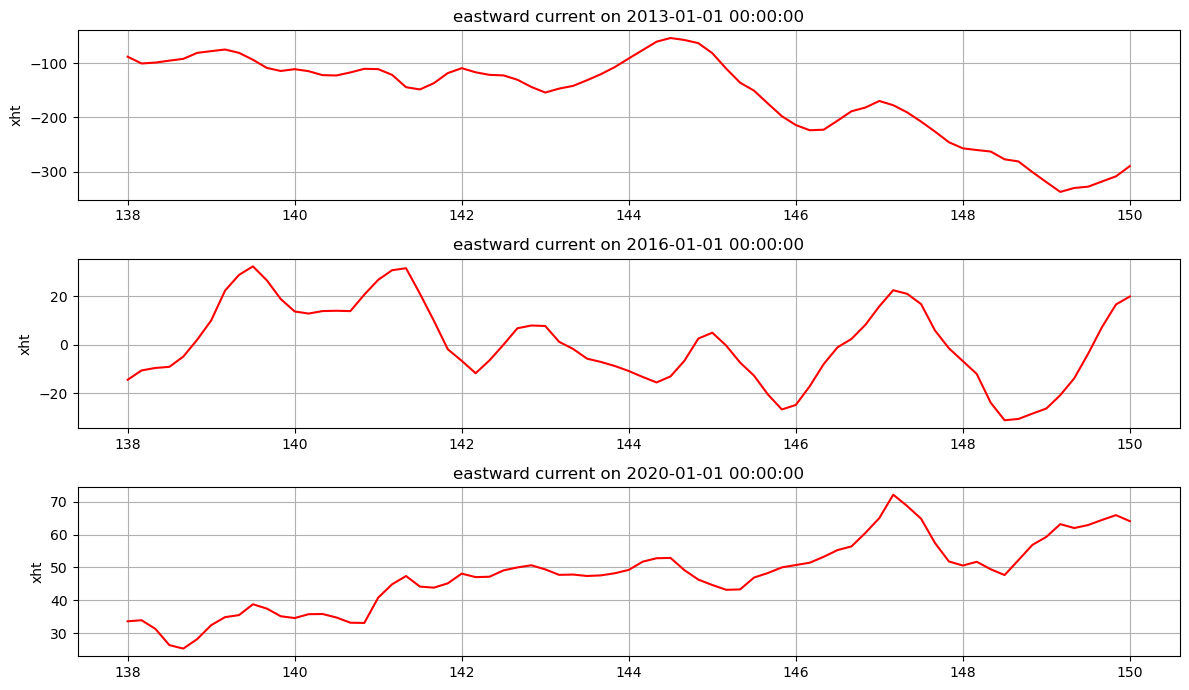

In [61]:
dsm = dsseg.mean('YC')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

xhtl = 'eastward current'
ax=axs[0]
ax.plot(dsm.XG,dsm.sel(time=t1).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XG,dsm.sel(time=t2).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XG,dsm.sel(time=t3).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t3))

plt.tight_layout()

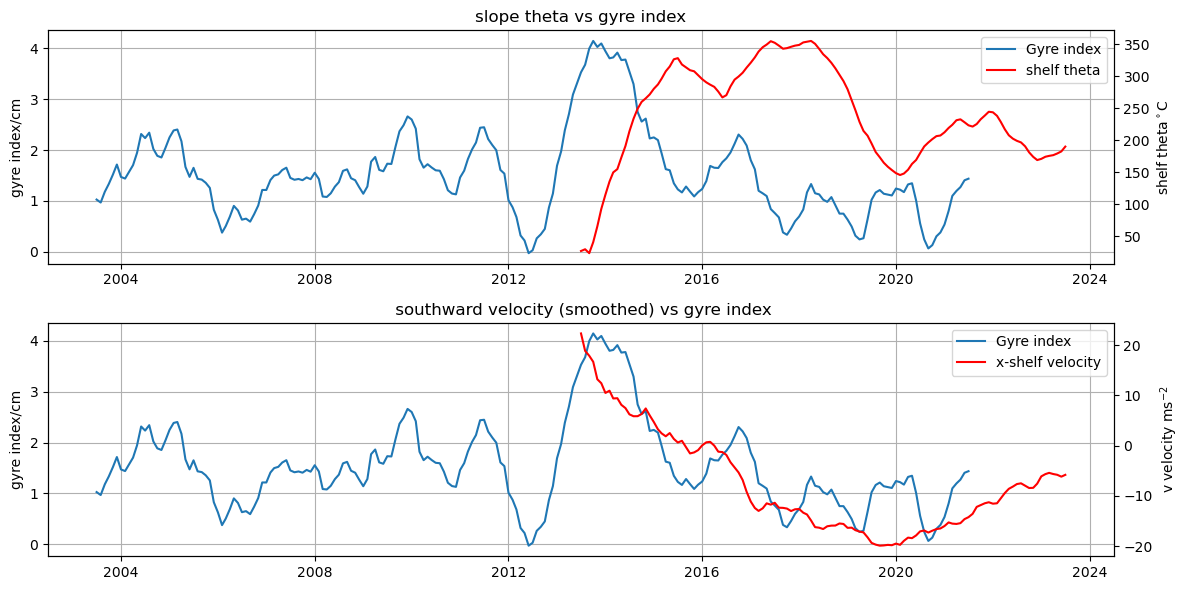

In [18]:
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
l1 = ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax2=ax.twinx()
l2 = ax2.plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','shelf theta'])
ax.grid()
ax2.set_ylabel(r'shelf theta$^\circ$C')
ax.set_ylabel('gyre index/cm')
ax.set_title('slope theta vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelf velocity'])
ax.grid()
ax2.set_ylabel(r'v velocity ms$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title(' southward velocity (smoothed) vs gyre index')

plt.tight_layout()

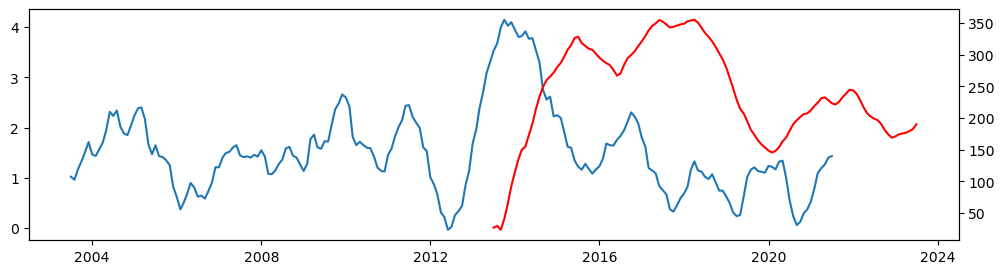

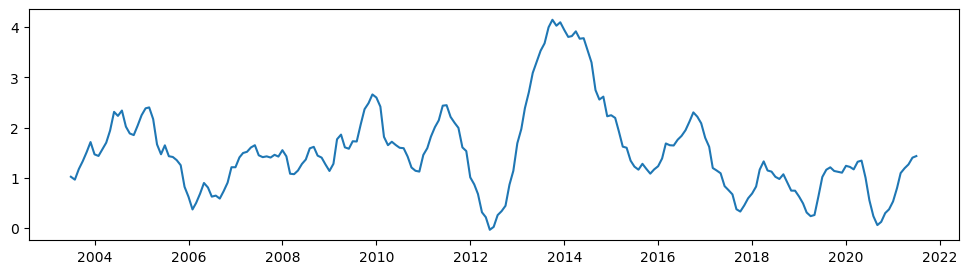

In [19]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())


In [20]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


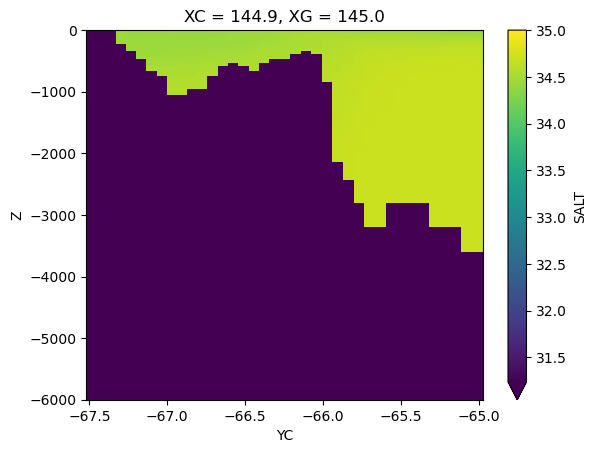

In [21]:
s_salty['spring'].mean('time').plot(vmin=35)

In [22]:
dss = fns.season_split(ds.sigma0)

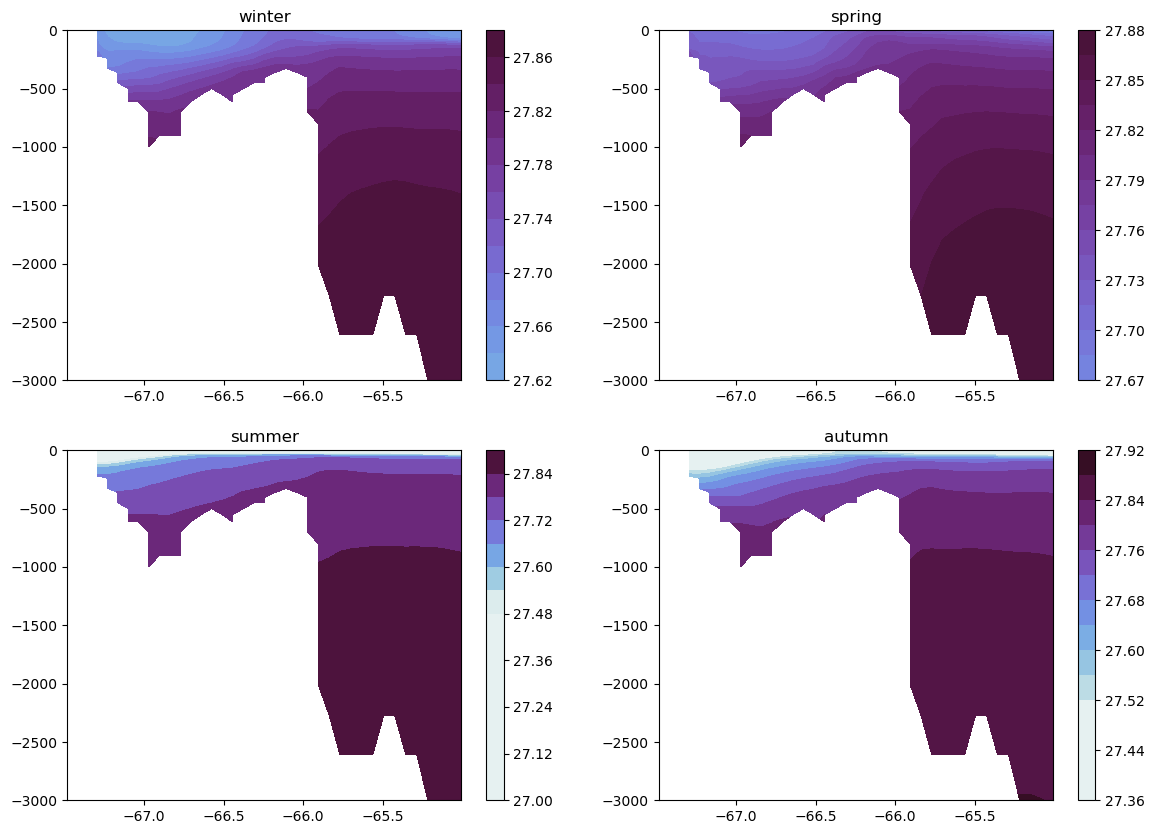

In [23]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [ ]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')